[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/josterri/predicting-the-next-words-notebooks/blob/main/ch06_workbook.ipynb)

# Attention weights

Attention scores every word of a sequence against a query, normalises the
scores into weights with a softmax, and combines the words' values with those
weights. The softmax weights a word by the exponential of its score, so the
ratio of two words' weights grows exponentially with the gap between their
scores.

In [1]:
#@title Setup: run this cell first
import math

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

WORDS = ("she", "read", "his", "letter", "again")
TOP = WORDS.index("letter")
TRIALS = 2000
D_MAX = 2048
D_MATCH = 32


def draw(d, trials=1):
    """trials random queries and trials sets of keys, one per word, of d components drawn with mean 0 and variance 1.
    The generator restarts at every call, so a step and its Solution score the same vectors."""
    assert isinstance(d, (int, np.integer)) and not isinstance(d, bool) and 1 <= d <= D_MAX, \
        f"D must be a whole number from 1 to {D_MAX:,}, and it is {d!r}"
    rng = np.random.default_rng(0)
    v = rng.standard_normal((trials, len(WORDS) + 1, d))
    return v[:, 0], v[:, 1:]


def dot_scores(q, K, scale=False):
    """q · k for each key k, divided by the square root of d when scale is True."""
    assert scale in (True, False), f"SCALE must be True or False, and it is {scale!r}"
    e = np.einsum("td,twd->tw", q, K)
    return e / math.sqrt(q.shape[-1]) if scale else e


def softmax(e):
    """exp(e) / Σ exp(e) along the last axis, the largest score subtracted first so no exp overflows."""
    z = np.exp(e - e.max(axis=-1, keepdims=True))
    return z / z.sum(axis=-1, keepdims=True)


def entropy_bits(w):
    """−Σ w log2 w along the last axis, with 0 · log2 0 taken as 0."""
    return -(w * np.log2(np.where(w > 0, w, 1))).sum(axis=-1)


def one_higher(top_score):
    """The five scores: "letter" scores top_score and the other four score 1."""
    #% abs(10**400) < 1e300 compares an int and a float exactly, where math.isfinite(10**400) overflows.
    shown = repr(top_score)
    assert isinstance(top_score, (int, float)) and abs(top_score) < 1e300, \
        f"TOP_SCORE must be a number between -1e300 and 1e300, such as 2, and it is {shown[:30]}{'…' * (len(shown) > 30)}"
    return np.array([top_score if i == TOP else 1 for i in range(len(WORDS))], dtype=float)


def ratio_of(gap):
    """e raised to the gap, or None where it overflows to inf or underflows to 0 in floating point."""
    with np.errstate(over="ignore", under="ignore"):
        r = np.exp(float(gap))
    return float(r) if np.isfinite(r) and r > 0 else None


def lead(gap):
    """The ratio of the weight of "letter" to each other word's, e raised to the gap between the scores, as a clause."""
    r = ratio_of(gap)
    if r is None:
        return f"the ratio, e raised to {gap:g}, has no floating-point value"
    return f'"letter" takes {r:,.4g} times the weight of each other word' if gap else \
        '"letter" takes the same weight as each other word'


def num(x):
    """x to two decimals without trailing zeros, or to three digits and a power of ten from a million up."""
    return f"{x:.3g}" if abs(x) >= 1e6 else f"{x:,.2f}".rstrip("0").rstrip(".")


def bars(scores, title=None):
    """The softmax weights of the five words as bars, each labelled with its weight, each word's score under it."""
    w = softmax(scores)
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.bar_label(ax.bar(range(len(WORDS)), w, tick_label=[f"{x}\n{num(s)}" for x, s in zip(WORDS, scores)]),
                 fmt=lambda v: f"{v:.5g}" if v > 0.999 else f"{v:.3g}")
    ax.set(xlabel="word, with its score under it", ylabel="attention weight", ylim=(0, 1.12))
    ax.set_title(title, fontsize=10)
    ax.set_yticks(np.linspace(0, 1, 6))
    plt.show()


def match_weights(match, d=D_MATCH):
    """Five queries' weights over the five words from scores divided by √d. With match, query i equals word i's key."""
    #% Unscaled at d = 32, random queries put up to 0.999 on one word, the saturation step 3 shows.
    assert match in (True, False), f"MATCH must be True or False, and it is {match!r}"
    q, K = draw(d, len(WORDS))
    return softmax((K[0] if match else q) @ K[0].T / math.sqrt(d))


def ink(rgba):
    """White on a cell darker than relative luminance 0.179, where white and black have equal contrast; else black."""
    lin = [c / 12.92 if c <= 0.04045 else ((c + 0.055) / 1.055) ** 2.4 for c in rgba[:3]]
    return "white" if 0.2126 * lin[0] + 0.7152 * lin[1] + 0.0722 * lin[2] < 0.179 else "black"


def heatmap(W, match):
    """W as a heatmap, one row per query and one column per word, every cell labelled with its weight."""
    fig, ax = plt.subplots(figsize=(6, 3.5))
    im = ax.imshow(W, cmap="Blues", vmin=0, vmax=1)
    fig.colorbar(im, ax=ax, label="attention weight")
    rows = list(WORDS) if match else [str(i + 1) for i in range(len(W))]
    ax.set(xticks=range(len(WORDS)), xticklabels=WORDS, yticks=range(len(W)), yticklabels=rows,
           xlabel="word whose key is scored", ylabel="query equal to the key of" if match else "random query")
    ax.set_title(f"d = {D_MATCH}, scores divided by √d", fontsize=10)
    for (i, j), v in np.ndenumerate(W):
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", color=ink(im.cmap(im.norm(v))))
    plt.show()


display(Markdown(f"A query scores {len(WORDS)} words, *{' '.join(WORDS)}*; random queries and keys have "
                 f"components drawn with mean 0 and variance 1."))

A query scores 5 words, *she read his letter again*; random queries and keys have components drawn with mean 0 and variance 1.

## 1. The softmax turns a gap in score into a ratio of weights

A query has scored five words: "letter" scores `TOP_SCORE` and the other four
score 1, and the bars are the weights the softmax gives them. Run the cell, then
run it again with `TOP_SCORE = 8`: how many times the weight of each other word
does "letter" take at each setting, and how does that follow from the gap
between the scores?

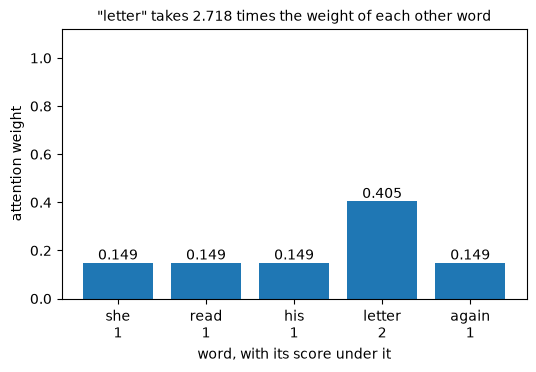

In [2]:
TOP_SCORE = 2
bars(one_higher(TOP_SCORE), title=lead(TOP_SCORE - 1))

### Solution

In [3]:
w, gap = softmax(one_higher(TOP_SCORE)), TOP_SCORE - 1
ratio = f", e raised to the gap of {gap:g} between the scores" if ratio_of(gap) is not None else ""
l1 = (f" Dividing each score by the sum of the scores would keep the ratio at {TOP_SCORE / 1:g}, the ratio of "
      f"the scores themselves." if TOP_SCORE > 0 else "")
display(Markdown(
    f"All five words score 1 and each takes {w[TOP]:.3f} of the weight, so the output is the mean of their values."
    if gap == 0 else
    f"\"letter\" takes {w[TOP]:.3g} of the weight and each other word {w[0]:.3g}; {lead(gap)}{ratio}. At "
    f"`TOP_SCORE = 8` the ratio is e raised to {8 - 1}, {math.exp(8 - 1):,.4g}.{l1}"))

"letter" takes 0.405 of the weight and each other word 0.149; "letter" takes 2.718 times the weight of each other word, e raised to the gap of 1 between the scores. At `TOP_SCORE = 8` the ratio is e raised to 7, 1,097. Dividing each score by the sum of the scores would keep the ratio at 2, the ratio of the scores themselves.

## 2. A query equal to one of five random keys puts almost all its weight on that key's word

Each row is one query's weights over the five words; the scores are dot
products of vectors with 32 components, divided by the square root of 32. With
`MATCH = True` query i equals the key of word i. Run the cell, then run it again with `MATCH = False`: what share of its
weight does each query put on the word whose key it equals, and where does the
weight go when the queries are random?

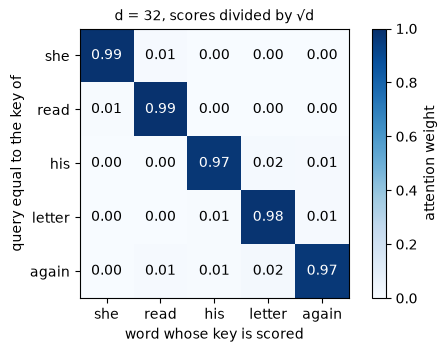

In [4]:
MATCH = True
heatmap(match_weights(MATCH), MATCH)

### Solution

In [5]:
same, rand = np.diag(match_weights(True)), match_weights(False)
hits = int((rand.argmax(axis=1) == np.arange(len(WORDS))).sum())
keys = draw(D_MATCH, len(WORDS))[1][0]
unit = keys / np.linalg.norm(keys, axis=1, keepdims=True)
cos = max(c for i, row in enumerate(unit @ unit.T) for j, c in enumerate(row) if i != j)
display(Markdown(
    f"A query equal to the key of a word puts between {same.min():.3f} and {same.max():.3f} of its weight on that "
    f"word. A random query puts between {np.diag(rand).min():.3f} and {np.diag(rand).max():.3f} on the word in the "
    f"same position; its largest weight, between {rand.max(axis=1).min():.3f} and {rand.max(axis=1).max():.3f}, "
    f"falls on that word for {hits or 'none'} of the {len(WORDS)} random queries. The match wins because five random "
    f"keys in {D_MATCH} dimensions lie nearly at right angles to each other: the largest cosine between two of them "
    f"is {cos:.2f}, so another key keeping its direction would need "
    + (f"{1 / cos:.2f} times the matching key's length to outscore it." if cos > 0 else "to point the query's way.")))

A query equal to the key of a word puts between 0.966 and 0.990 of its weight on that word. A random query puts between 0.053 and 0.269 on the word in the same position; its largest weight, between 0.327 and 0.644, falls on that word for none of the 5 random queries. The match wins because five random keys in 32 dimensions lie nearly at right angles to each other: the largest cosine between two of them is 0.21, so another key keeping its direction would need 4.81 times the matching key's length to outscore it.

## 3. Unscaled dot products in 256 dimensions put the weight on one word

A random query scores the five words' random keys, each of `D` components
drawn with mean 0 and variance 1. Run the cell, then run it again with
`SCALE = True`, which divides every score by the square root of `D` as step 2
does: what share of the weight does the top word take at each setting?

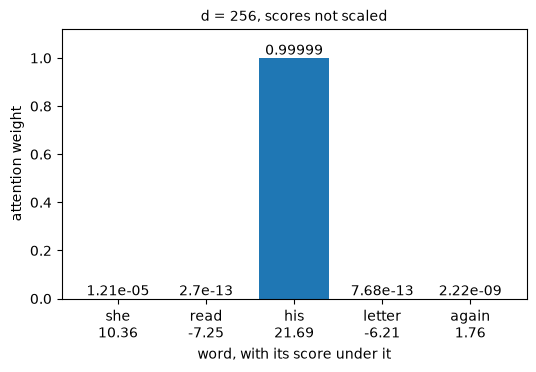

In [6]:
SCALE = False
D = 256
e = dot_scores(*draw(D), SCALE)[0]
bars(e, title=f"d = {D}, scores {'divided by √d' if SCALE else 'not scaled'}")

### Solution

In [7]:
q, K = draw(D)
raw, scaled = dot_scores(q, K)[0], dot_scores(q, K, True)[0]
w0, w1, top = softmax(raw), softmax(scaled), WORDS[raw.argmax()]
display(Markdown(
    f"At d = {D} the unscaled scores run from {raw.min():.2f} to {raw.max():.2f}, and \"{top}\" takes "
    f"{w0.max():.5f} of the weight. Divided by √{D} = {math.sqrt(D):.1f}, they run from {scaled.min():.2f} to "
    f"{scaled.max():.2f}, and \"{top}\" takes {w1.max():.3f}. The entropy of the weights is {entropy_bits(w0):.2f} "
    f"bits unscaled and {entropy_bits(w1):.2f} bits scaled, of at most {math.log2(len(WORDS)):.2f}."))

At d = 256 the unscaled scores run from -7.25 to 21.69, and "his" takes 0.99999 of the weight. Divided by √256 = 16.0, they run from -0.45 to 1.36, and "his" takes 0.472. The entropy of the weights is 0.00 bits unscaled and 1.97 bits scaled, of at most 2.32.

## Appendix. Dot products grow like √d, and the softmax saturates

A query q scores the key k_j of each word j, normalises the scores with a
softmax and combines the words' values v_j:

e_j = q · k_j = Σ_i q_i k_ji,  α_j = exp(e_j) / Σ_m exp(e_m),  c = Σ_j α_j v_j.

When the d components of q and of k_j are independent with mean 0 and variance
1, the score q · k_j has mean 0 and variance d, so its standard deviation is
√d. As d grows the scores of the T words, five here, lie further apart, and the softmax
saturates: one weight approaches 1 and the others approach 0. The gradient of
the weights with respect to the scores,

∂α_i / ∂e_j = α_i (δ_ij − α_j),  with δ_ij equal to 1 when i and j are equal and 0 otherwise,

is then near 0 for every i and j, and training moves the scores little.
Dividing every score by √d, e_j = q · k_j / √d, brings their standard deviation
back to 1 at every d.

The entropy H = −Σ_j α_j log2 α_j measures how far the weights spread: 0 bits
when one word takes all the weight, log2 T bits when the T words take equal
shares. Its mean over 2,000 random queries, each scoring its own random keys,
for d from 4 to 512:

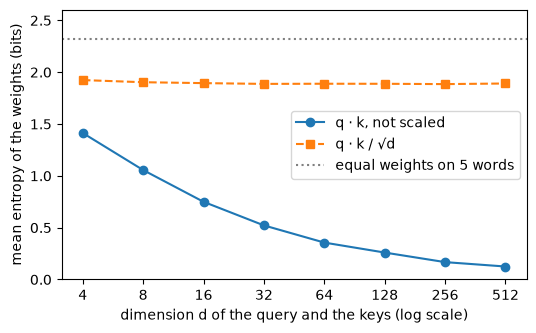

In [8]:
ds = [4, 8, 16, 32, 64, 128, 256, 512]
H = {s: [entropy_bits(softmax(dot_scores(*draw(d, TRIALS), s))).mean() for d in ds] for s in (False, True)}
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(ds, H[False], "o-", label="q · k, not scaled")
ax.plot(ds, H[True], "s--", label="q · k / √d")
ax.axhline(math.log2(len(WORDS)), color="gray", ls=":", label=f"equal weights on {len(WORDS)} words")
ax.set_xscale("log", base=2)
ax.set_xticks(ds, labels=[str(d) for d in ds])
ax.minorticks_off()
ax.set(xlabel="dimension d of the query and the keys (log scale)", ylabel="mean entropy of the weights (bits)",
       ylim=(0, 2.6))
ax.legend(loc="center right")
plt.show()

**Exercise.** Set `D` to 4, 16, 64 and 512 in turn and rerun the cell. What mean
weight does the top word take at each d, without the division by √d and with
it?

In [9]:
D = 64

e = dot_scores(*draw(D, TRIALS))
print(f"d = {D}: the top word takes a mean weight of {softmax(e).max(axis=-1).mean():.3f} not scaled "
      f"and {softmax(e / math.sqrt(D)).max(axis=-1).mean():.3f} scaled")

d = 64: the top word takes a mean weight of 0.902 not scaled and 0.461 scaled


### Solution

In [10]:
sd = [dot_scores(*draw(d, TRIALS)).std() for d in ds]
top = {s: [softmax(dot_scores(*draw(d, TRIALS), s)).max(axis=-1).mean() for d in ds] for s in (False, True)}
display(Markdown("| d | sd of q · k | top weight, not scaled | top weight, scaled |\n| ---: | ---: | ---: | ---: |\n"
                 + "\n".join(f"| {d} | {s:.2f} | {t0:.3f} | {t1:.3f} |"
                             for d, s, t0, t1 in zip(ds, sd, top[False], top[True]))))
display(Markdown(
    f"Without the division the top word's mean weight rises from {top[False][0]:.3f} at d = {ds[0]} to "
    f"{top[False][-1]:.3f} at d = {ds[-1]}, as the standard deviation of the scores grows from {sd[0]:.2f} to "
    f"{sd[-1]:.1f}, and the mean entropy falls from {H[False][0]:.2f} to {H[False][-1]:.2f} bits. With it, the "
    f"top word's mean weight stays between {min(top[True]):.3f} and {max(top[True]):.3f}, and the entropy between "
    f"{min(H[True]):.2f} and {max(H[True]):.2f} bits of the {math.log2(len(WORDS)):.2f} bits of equal weights."))

| d | sd of q · k | top weight, not scaled | top weight, scaled |
| ---: | ---: | ---: | ---: |
| 4 | 1.99 | 0.608 | 0.440 |
| 8 | 2.82 | 0.712 | 0.452 |
| 16 | 3.96 | 0.795 | 0.456 |
| 32 | 5.71 | 0.857 | 0.459 |
| 64 | 7.97 | 0.902 | 0.461 |
| 128 | 11.15 | 0.927 | 0.461 |
| 256 | 15.98 | 0.953 | 0.462 |
| 512 | 22.66 | 0.964 | 0.459 |

Without the division the top word's mean weight rises from 0.608 at d = 4 to 0.964 at d = 512, as the standard deviation of the scores grows from 1.99 to 22.7, and the mean entropy falls from 1.41 to 0.13 bits. With it, the top word's mean weight stays between 0.440 and 0.462, and the entropy between 1.89 and 1.92 bits of the 2.32 bits of equal weights.